In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [29]:
data = pd.read_csv("housing.csv")

In [30]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [32]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [33]:
data.dropna(inplace=True)
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# EDA 
* Now before starting with training the model lets inspect the training data. Use join function to join 2 dataframes x_train & y_train together and analyze them

In [37]:
train_data = x_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
4212,-118.26,34.11,52.0,1740.0,402.0,749.0,335.0,3.5673,<1H OCEAN,270700.0
14005,-117.18,32.76,52.0,2023.0,301.0,649.0,285.0,4.7396,NEAR OCEAN,441700.0
1844,-122.28,37.91,38.0,2501.0,348.0,805.0,329.0,6.5576,NEAR BAY,358500.0
17635,-121.92,37.28,26.0,6201.0,783.0,2381.0,819.0,7.9819,<1H OCEAN,397000.0
19950,-119.34,36.23,12.0,4965.0,872.0,2191.0,804.0,3.5611,INLAND,90200.0
...,...,...,...,...,...,...,...,...,...,...
19258,-122.73,38.46,14.0,2324.0,754.0,1026.0,677.0,1.7220,<1H OCEAN,150000.0
6036,-117.73,34.06,34.0,344.0,108.0,315.0,119.0,3.1786,INLAND,117800.0
8895,-118.49,34.03,31.0,3155.0,808.0,1208.0,745.0,3.6769,<1H OCEAN,450000.0
15560,-117.06,33.09,11.0,7483.0,1276.0,3516.0,1261.0,4.0484,<1H OCEAN,262500.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

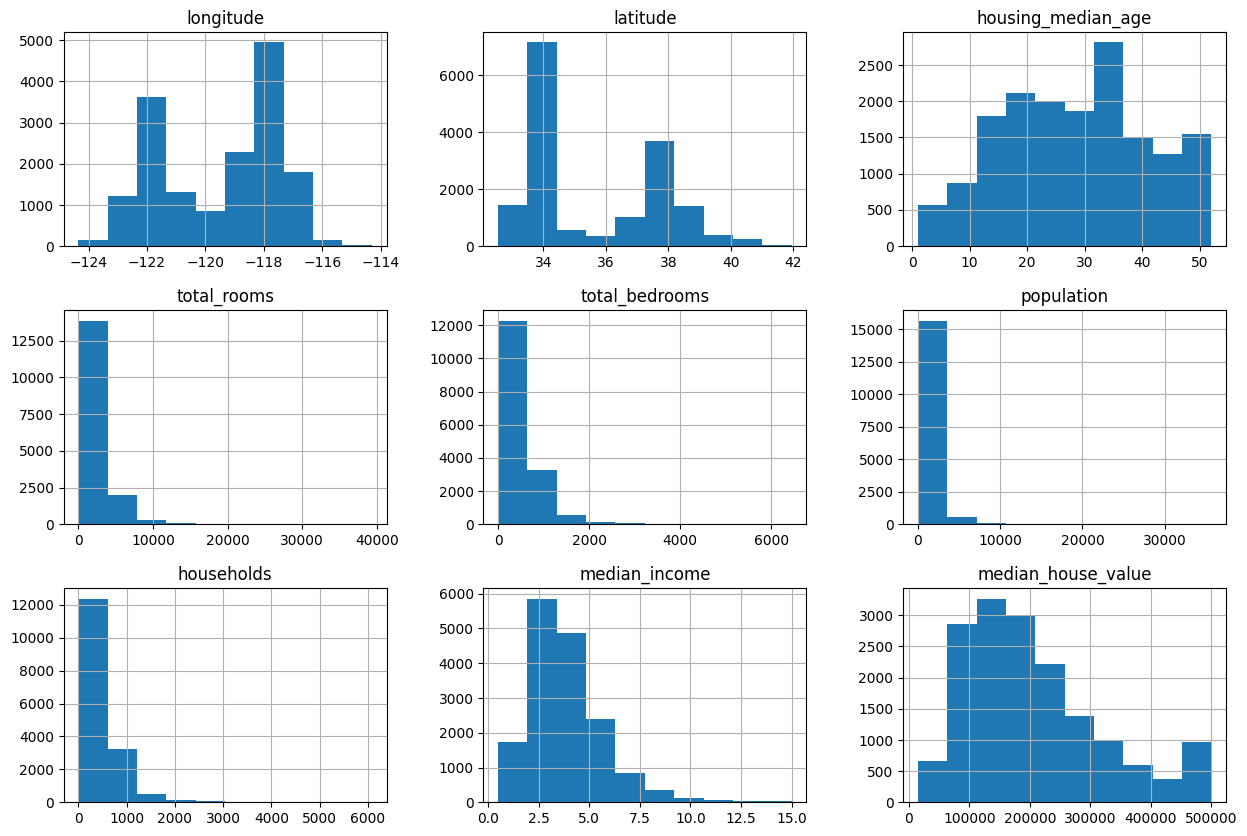

In [38]:
train_data.hist(figsize=(15, 10))

<Axes: >

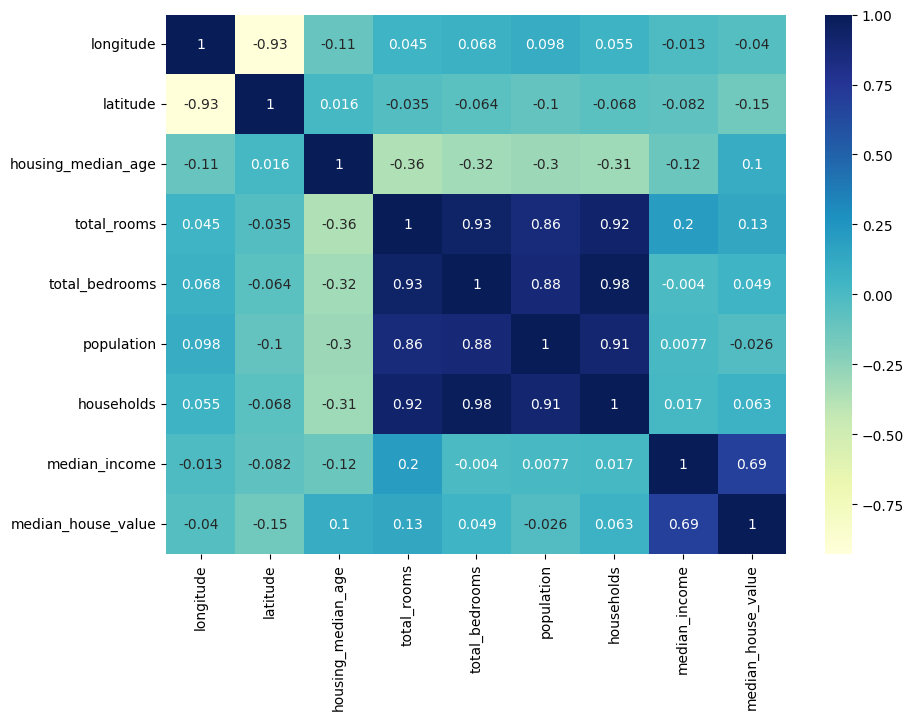

In [39]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu") 
# "numeric_onlt=True" is used here to ignore any text based data (e.g. Ocean_proximity) which cannot be plotted.

# Preprocessing (Skewed Curve)
* As we can see in the histogram plot from earlier, there are a few features that are skewed curve, doesnt ressmble gaussian curve. we convert them using log function to get a bell curve that is much more suited to train the model than the raw data.

In [40]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

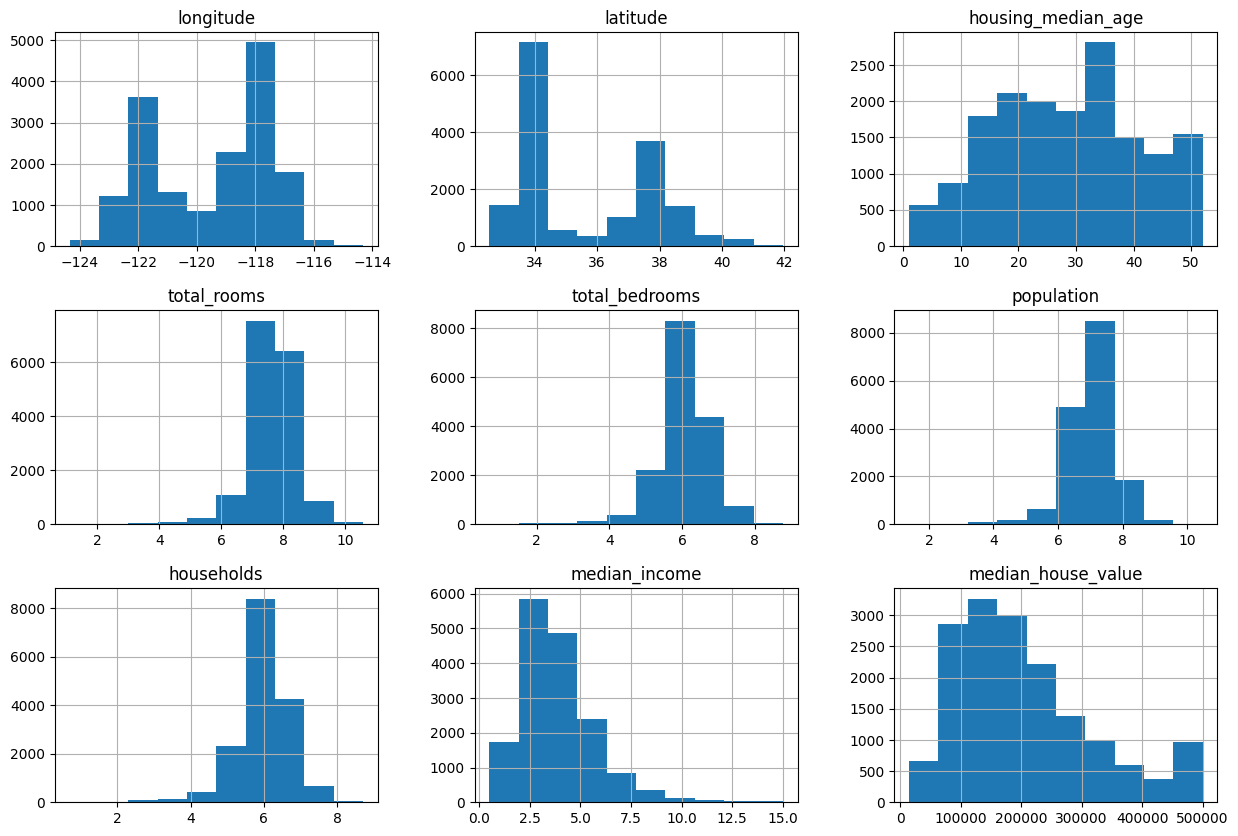

In [41]:
train_data.hist(figsize=(15,10))

### (Features with categorical data)
* e.g. Ocean_proximity is a kind of data that cannot be used directly as it is categorical. We can convert each of the categories into multiple features so that we can better train the model.

In [42]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7234
INLAND        5173
NEAR OCEAN    2114
NEAR BAY      1821
ISLAND           4
Name: count, dtype: int64

In [43]:
pd.get_dummies(train_data.ocean_proximity) 
# pd.get_dummies is used to convert the categorical data into binary(0-1 or True-False), As you can see below one feature is being converted into multiple features.

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4212,True,False,False,False,False
14005,False,False,False,False,True
1844,False,False,False,True,False
17635,True,False,False,False,False
19950,False,True,False,False,False
...,...,...,...,...,...
19258,True,False,False,False,False
6036,False,True,False,False,False
8895,True,False,False,False,False
15560,True,False,False,False,False


In [44]:
# you can add this data into the train_data df using join.
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity))

In [45]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4212,-118.26,34.11,52.0,7.462215,5.998937,6.620073,5.817111,3.5673,<1H OCEAN,270700.0,True,False,False,False,False
14005,-117.18,32.76,52.0,7.612831,5.710427,6.476972,5.655992,4.7396,NEAR OCEAN,441700.0,False,False,False,False,True
1844,-122.28,37.91,38.0,7.824846,5.855072,6.692084,5.799093,6.5576,NEAR BAY,358500.0,False,False,False,True,False
17635,-121.92,37.28,26.0,8.732627,6.664409,7.775696,6.709304,7.9819,<1H OCEAN,397000.0,True,False,False,False,False
19950,-119.34,36.23,12.0,8.510370,6.771936,7.692570,6.690842,3.5611,INLAND,90200.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19258,-122.73,38.46,14.0,7.751475,6.626718,6.934397,6.519147,1.7220,<1H OCEAN,150000.0,True,False,False,False,False
6036,-117.73,34.06,34.0,5.843544,4.691348,5.755742,4.787492,3.1786,INLAND,117800.0,False,True,False,False,False
8895,-118.49,34.03,31.0,8.057061,6.695799,7.097549,6.614726,3.6769,<1H OCEAN,450000.0,True,False,False,False,False
15560,-117.06,33.09,11.0,8.920523,7.152269,8.165364,7.140453,4.0484,<1H OCEAN,262500.0,True,False,False,False,False


In [46]:
# now ocean_proximity is no longer needed, drop it
train_data.drop(["ocean_proximity"], axis=1, inplace=True)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4212,-118.26,34.11,52.0,7.462215,5.998937,6.620073,5.817111,3.5673,270700.0,True,False,False,False,False
14005,-117.18,32.76,52.0,7.612831,5.710427,6.476972,5.655992,4.7396,441700.0,False,False,False,False,True
1844,-122.28,37.91,38.0,7.824846,5.855072,6.692084,5.799093,6.5576,358500.0,False,False,False,True,False
17635,-121.92,37.28,26.0,8.732627,6.664409,7.775696,6.709304,7.9819,397000.0,True,False,False,False,False
19950,-119.34,36.23,12.0,8.510370,6.771936,7.692570,6.690842,3.5611,90200.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19258,-122.73,38.46,14.0,7.751475,6.626718,6.934397,6.519147,1.7220,150000.0,True,False,False,False,False
6036,-117.73,34.06,34.0,5.843544,4.691348,5.755742,4.787492,3.1786,117800.0,False,True,False,False,False
8895,-118.49,34.03,31.0,8.057061,6.695799,7.097549,6.614726,3.6769,450000.0,True,False,False,False,False
15560,-117.06,33.09,11.0,8.920523,7.152269,8.165364,7.140453,4.0484,262500.0,True,False,False,False,False


<Axes: >

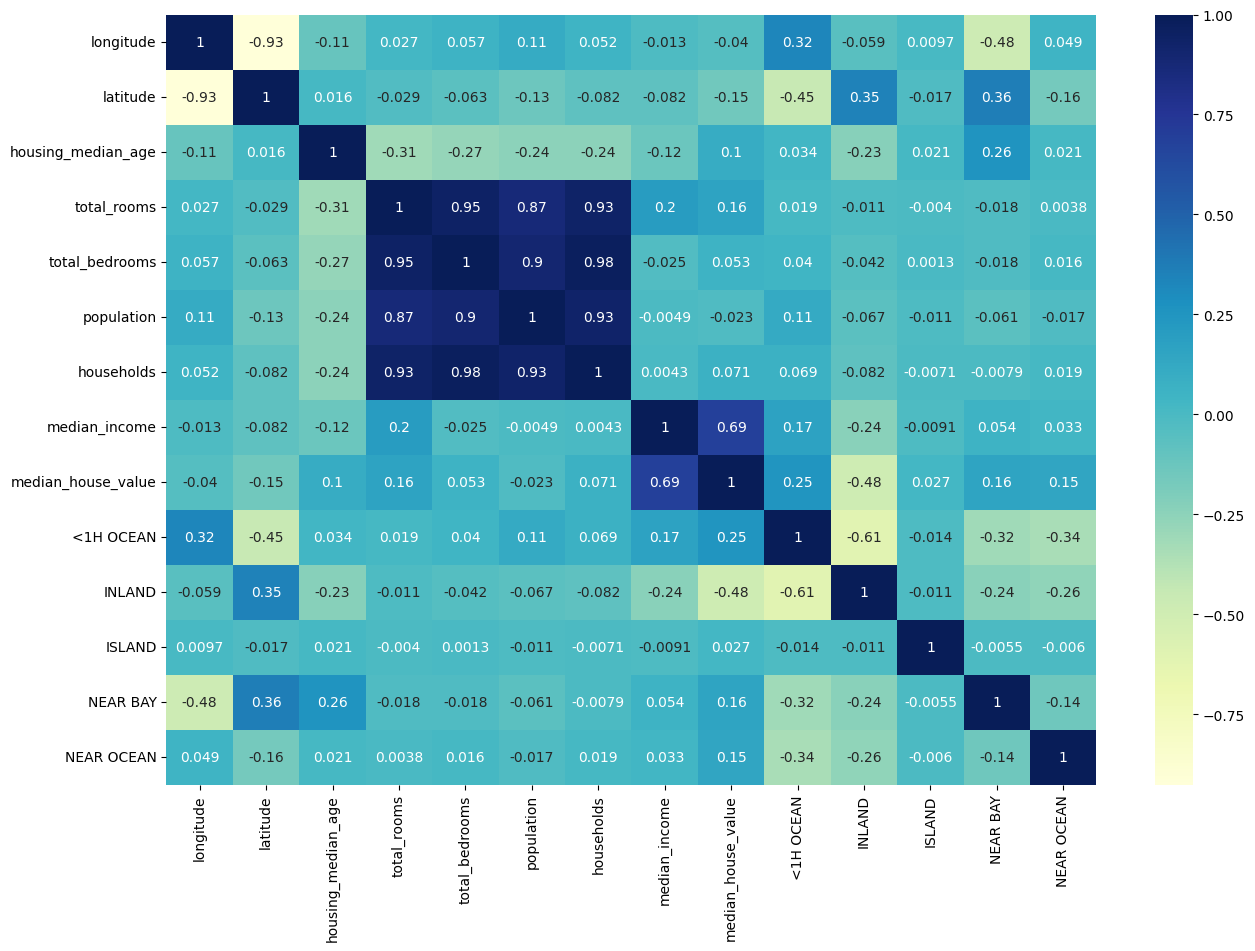

In [47]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu") 

<Axes: xlabel='latitude', ylabel='longitude'>

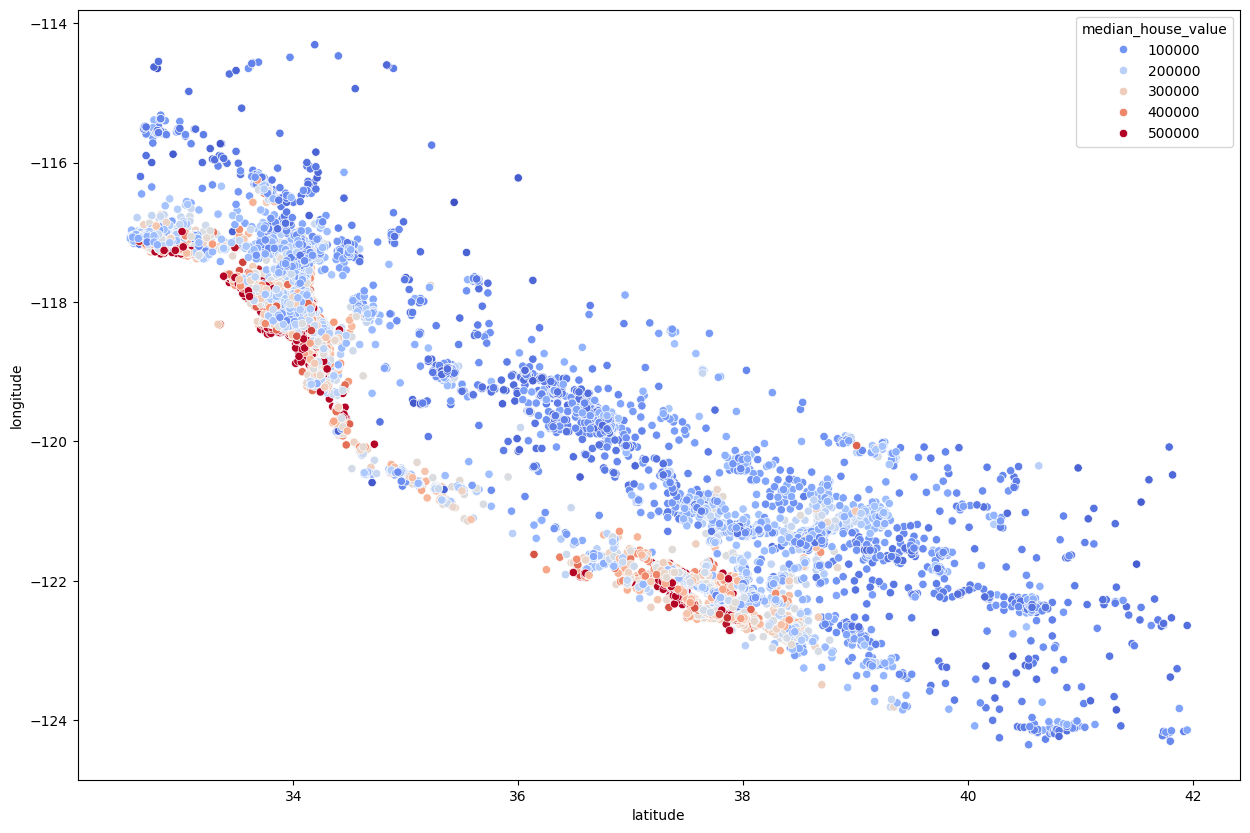

In [48]:
# An interesting vizualization if you have map data(latitude & longitude), hue is what the dot represents in the below example it is the price of house
plt.figure(figsize=(15, 10))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

# Feature Engineering

In [49]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['house_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

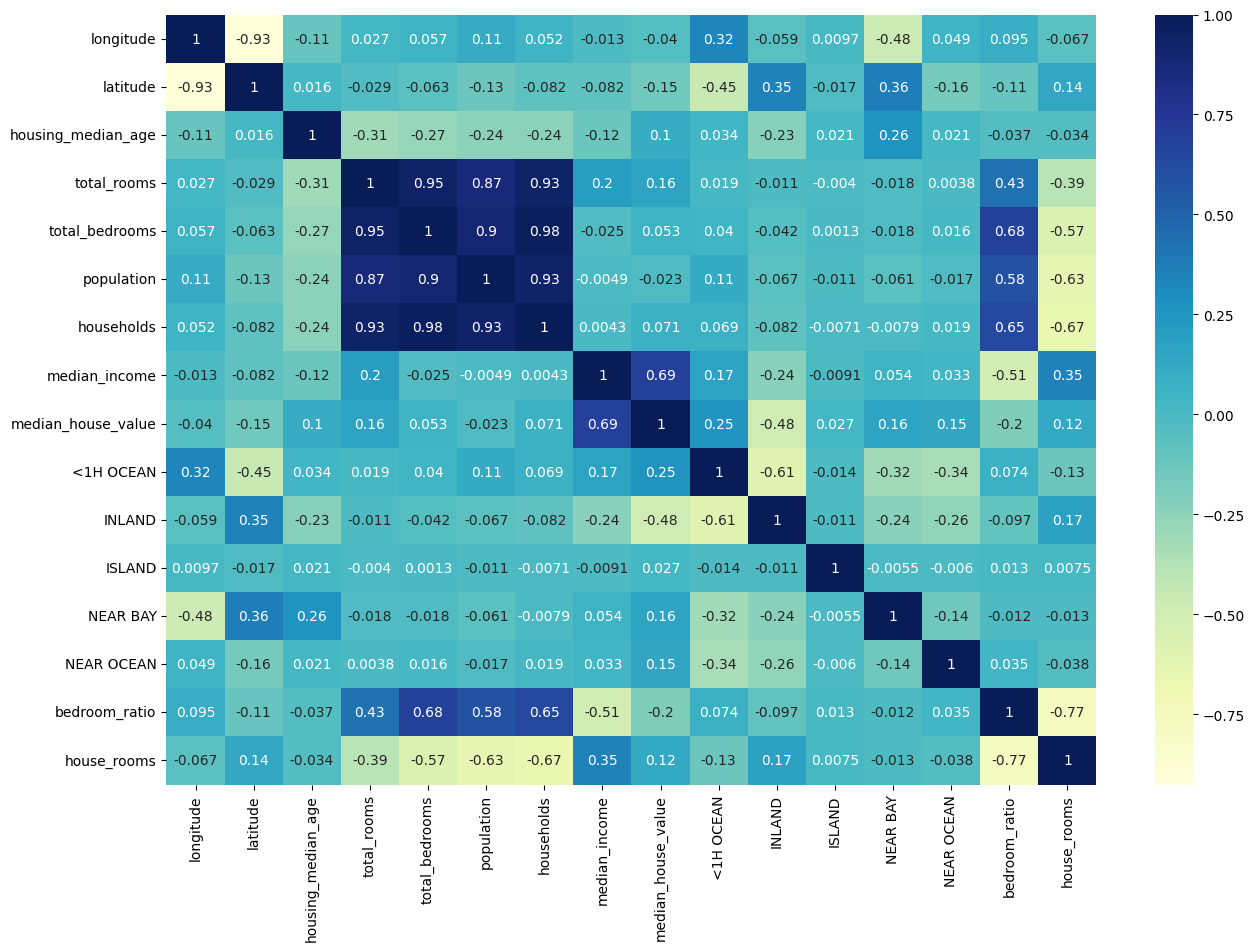

In [50]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu") 

# Linear Regression

In [53]:
from sklearn.linear_model import LinearRegression

x_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']

reg = LinearRegression()

reg.fit(x_train, y_train)

LinearRegression()

In [54]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity))
test_data.drop(["ocean_proximity"], axis=1, inplace=True)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['house_rooms'] = test_data['total_rooms'] / test_data['households']

In [55]:
x_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [56]:
reg.score(x_test, y_test)

np.float64(0.6829843641445299)